In [1]:
import os
import cv2
import torch
from PIL import Image
import supervision as sv
import matplotlib as plt
from transformers import DetrForObjectDetection, DetrImageProcessor

In [2]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

MODEL_PATH = "/home/ncaytuir/data/ArchaIA_Project/Object-Detection/finetuned_models/303artifacts_70epochs"

CONFIDENCE_TRESHOLD = 0.5
IOU_TRESHOLD = 0.8

image_processor = DetrImageProcessor.from_pretrained(MODEL_PATH)
model = DetrForObjectDetection.from_pretrained(MODEL_PATH)
model.to(DEVICE)

/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/torch/nn/modules/module.py:2400: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/torch/nn/modules/module.py:2400: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/torch/nn/modules/module.py:2400: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpo

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      

Inference with non-max supression

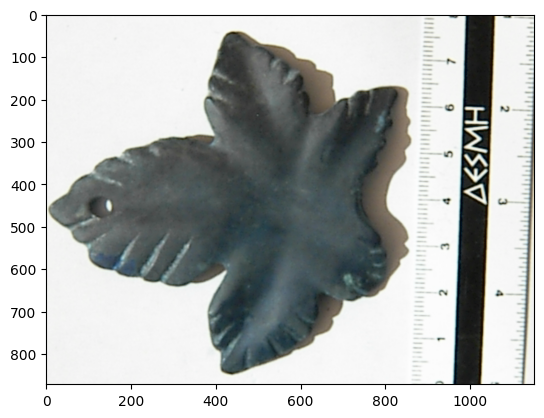

In [4]:
import matplotlib.pyplot as plt2

#IMAGE_PATH = "/home/ncaytuir/data/ArchaIA_Project/FilteredData/artifact_0377.jpg"
IMAGE_PATH = "/home/ncaytuir/data/ArchaIA_Project/FilteredData/artifact_0044.jpg"

original_image = cv2.imread(IMAGE_PATH)

# Display the image using Matplotlib
plt2.imshow(original_image)
plt2.show()

#img = Image.open(IMAGE_PATH)
#img

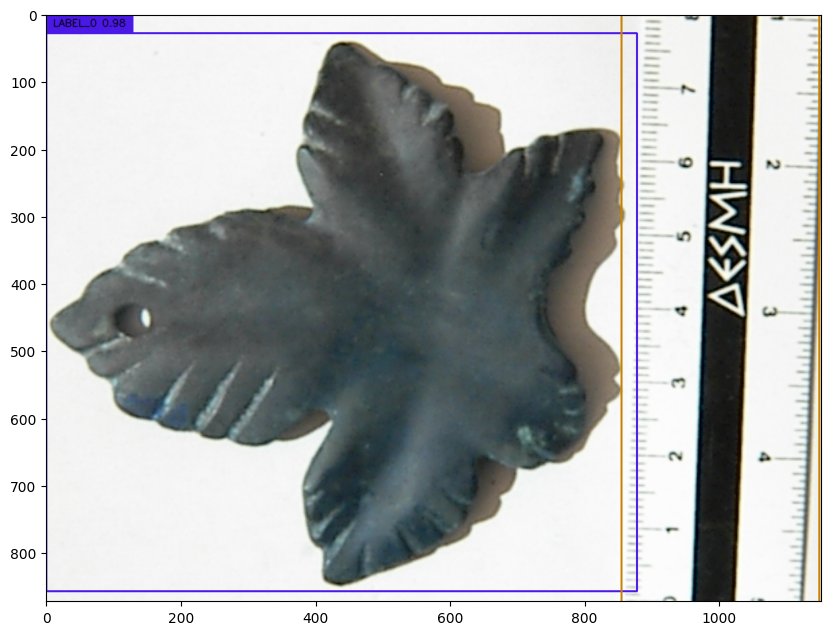

In [5]:
def make_detections(original_image):
    with torch.no_grad():
        # Load image and predict
        image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
        inputs = image_processor(images=image, return_tensors="pt").to(DEVICE)
        outputs = model(**inputs)

        # Post-process
        target_sizes = torch.tensor([image.shape[:2]]).to(DEVICE)
        results = image_processor.post_process_object_detection(
            outputs=outputs,
            threshold=CONFIDENCE_TRESHOLD,
            target_sizes=target_sizes
        )[0]

    # Annotate
    detections = sv.Detections.from_transformers(transformers_results=results).with_nms(threshold=IOU_TRESHOLD)

    labels = [
        f"{model.config.id2label[class_id]} {confidence:0.2f}" 
        for _, confidence, class_id, _ 
        in detections
    ]

    box_annotator = sv.BoxAnnotator()
    frame = box_annotator.annotate(scene=original_image.copy(), detections=detections, labels=labels)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    return detections, frame

%matplotlib inline
detections, frame = make_detections(original_image)
sv.show_frame_in_notebook(frame, (10, 8))

In [5]:
print(detections)
print(detections.xyxy)
print(detections.class_id)
print(detections.confidence)

Detections(xyxy=array([[9.6154404e-01, 2.8754787e+01, 8.7848755e+02, 8.5797284e+02],
       [8.5538031e+02, 1.9268785e+00, 1.1498706e+03, 8.7392432e+02]],
      dtype=float32), class_id=array([0, 3]), confidence=array([0.97638285, 0.77756864], dtype=float32), tracker_id=None)
[[9.6154404e-01 2.8754787e+01 8.7848755e+02 8.5797284e+02]
 [8.5538031e+02 1.9268785e+00 1.1498706e+03 8.7392432e+02]]
[0 3]
[0.97638285 0.77756864]


In [6]:
for i in range(len(detections.class_id)):
    if detections.class_id[i] == 0:
        print(detections.xyxy[i])

[  0.96154404  28.754787   878.48755    857.97284   ]


Crop image with DETR detections

In [6]:
%matplotlib inline 

def crop_image_with_detections(original_image, detections):

    cropped_images = []

    for i in range(len(detections.class_id)):
        if detections.class_id[i] == 0:
            #cropped_image = sv.crop_image(image=image, xyxy=detections.xyxy[i])

            # Obtain bbox
            x1, y1, x2, y2 = detections.xyxy[i]

            # Convert to integers
            x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

            # Crop
            cropped_image = original_image[y1:y2, x1:x2]
            #cropped_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)

            cropped_images.append(cropped_image)

            #sv.show_frame_in_notebook(cropped_image, (10, 8))
        
    return cropped_images

cropped_images = crop_image_with_detections(original_image, detections)
print(len(cropped_images))

1


Remove bg with BRIA

In [ ]:
import os
import gradio as gr
from gradio_imageslider import ImageSlider
from loadimg import load_img
import spaces
from transformers import AutoModelForImageSegmentation
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

torch.set_float32_matmul_precision(["high", "highest"][0])

access_token = "#"

birefnet = AutoModelForImageSegmentation.from_pretrained(
    "briaai/RMBG-2.0", trust_remote_code=True, token=access_token#, low_cpu_mem_usage=False
)
birefnet.to("cuda")
transform_image = transforms.Compose(
    [
        transforms.Resize((1024, 1024)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [8]:
def fn(image):
    #print(image)
    #im = load_img(image, output_type="pil")
    #im = im.convert("RGB")
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    im = Image.fromarray(rgb_image)
    original = im.copy()
    processed_image = process(im)
    return processed_image, original

@spaces.GPU
def process(image):
    image_size = image.size
    input_images = transform_image(image).unsqueeze(0).to("cuda")
    # Prediction
    with torch.no_grad():
        preds = birefnet(input_images)[-1].sigmoid().cpu()
    pred = preds[0].squeeze()
    pred_pil = transforms.ToPILImage()(pred)
    mask = pred_pil.resize(image_size)
    image.putalpha(mask)
    return image

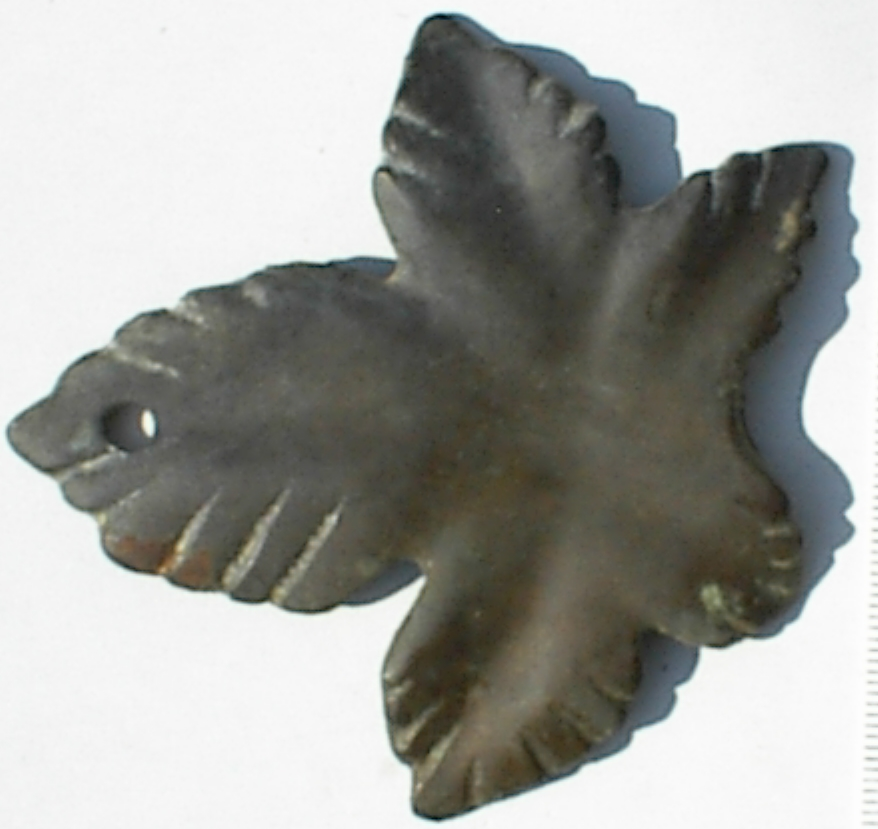

In [9]:

imagen_rgb = cv2.cvtColor(cropped_images[0], cv2.COLOR_BGR2RGB)
imagen = Image.fromarray(imagen_rgb)
imagen

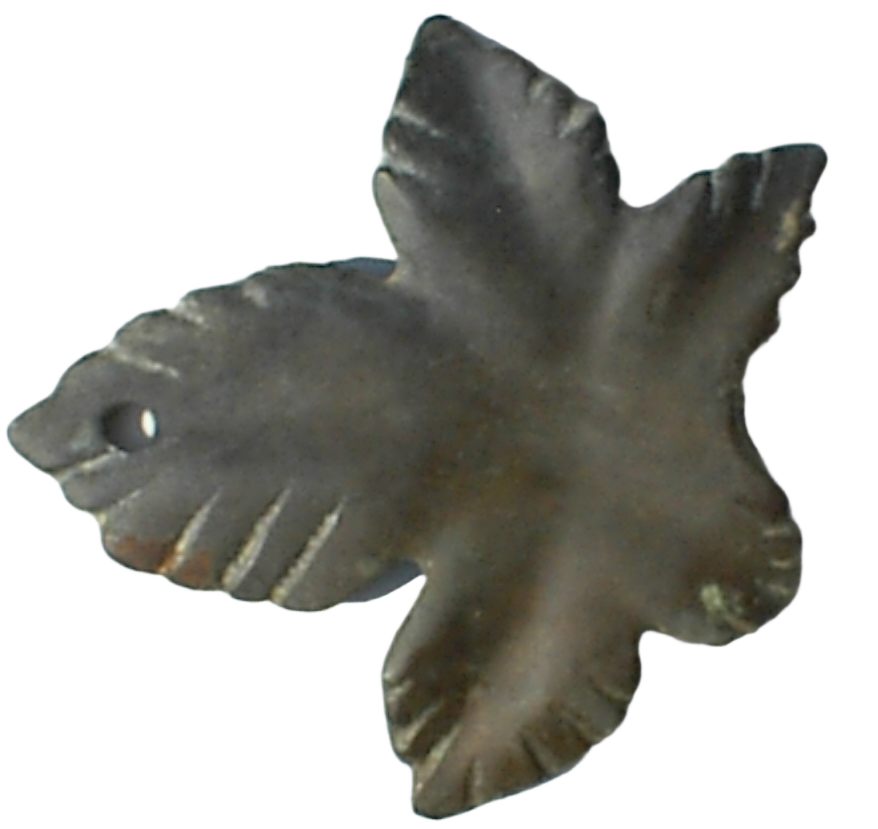

In [11]:
for i in range(len(cropped_images)):
    processed_image, original = fn(cropped_images[i])
processed_image

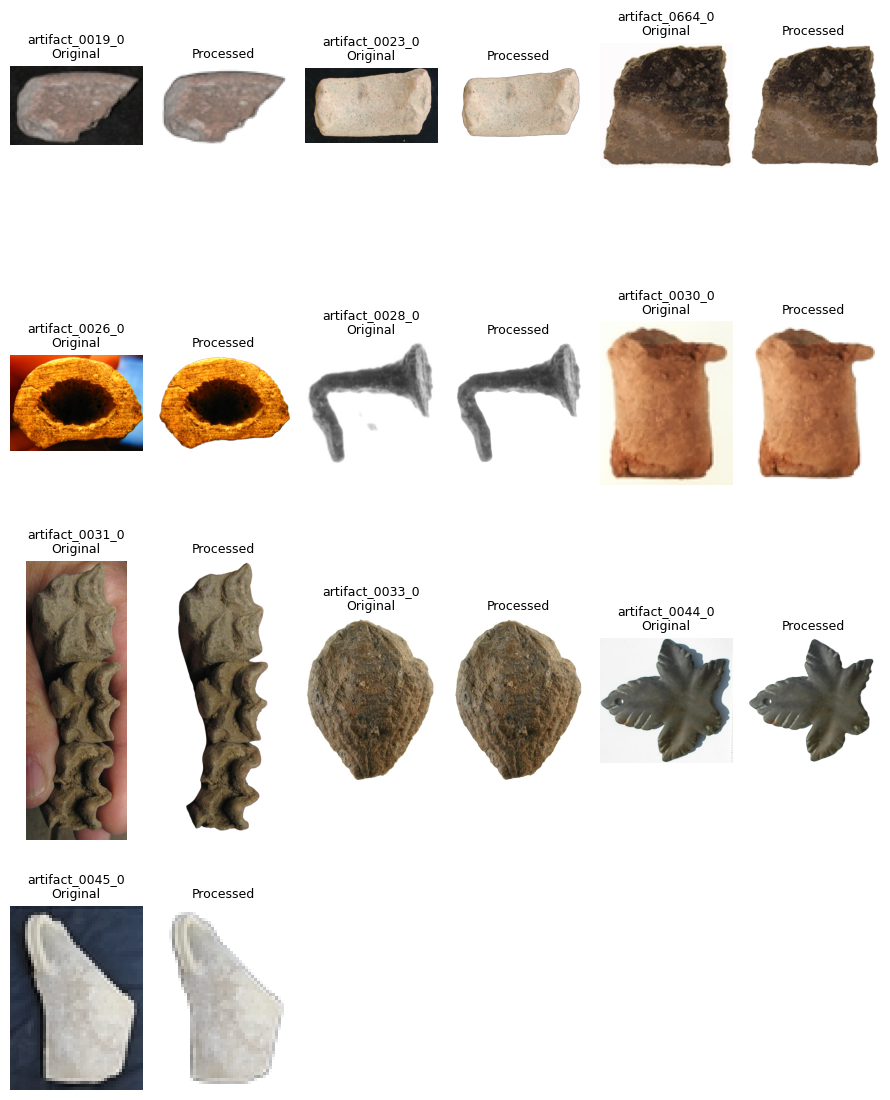

In [22]:
from pathlib import Path

image_names = ["artifact_0019.jpg", "artifact_0023.jpg", "artifact_0664.jpg", "artifact_0026.jpg", "artifact_0028.jpg", "artifact_0030.jpg", "artifact_0031.jpg", "artifact_0033.jpg", "artifact_0044.jpg", "artifact_0045.jpg"] # , "artifact_0001.jpg", "artifact_0004.jpg", "artifact_0005.jpg", "artifact_0661.jpg", "artifact_0654.jpg", "artifact_0012.jpg", "artifact_0014.jpg", "artifact_0015.jpg", "artifact_0016.jpg", "artifact_0018.jpg"

image_path = "/home/ncaytuir/data/ArchaIA_Project/FilteredData/"

columns = 6
rows = 5

fig = plt.figure(figsize=(9, rows*3))

subplot_idx = 1

for i in image_names:
    image_id = i.split('.', 1)[0]

    original_image = cv2.imread(Path(image_path+i))
    detections, frame = make_detections(original_image)

    cropped_images = crop_image_with_detections(original_image, detections)

    for j in range(len(cropped_images)):
        processed_image, original = fn(cropped_images[j])

        # Convertir correctamente
        original_rgb = original.convert("RGB")
        #processed_rgb = processed_image.convert("RGB")

        # Add image to plt grid
        ax1 = fig.add_subplot(rows, columns, subplot_idx)
        ax1.imshow(original_rgb)
        ax1.set_title(f"{image_id}_{j}\nOriginal", fontsize=9)
        ax1.axis("off")

        subplot_idx += 1

        ax2 = fig.add_subplot(rows, columns, subplot_idx)
        ax2.imshow(processed_image)
        ax2.set_title("Processed", fontsize=9)
        ax2.axis("off")

        subplot_idx += 1

plt.tight_layout()
plt.savefig("original_vs_processed2.png", dpi=300, bbox_inches="tight")
plt.show()